# Pymol Tutorial - Alternate version

Today we’re going to work through an introduction to protein structural visualization using PyMOL, a widely used molecular graphics system for 3D visualization, rendering, and analysis of biological macromolecules. Structural data are central to  biology and can allow us to understand how proteins function and how human disease mutations may impact their physiology. Thus, being able to visualize and interrogate a protein structure is  a powerful and broadly applicable research skill.

PyMOL allows us to import experimentally determined structures from the Protein Data Bank as well as predicted models (such as those generated by AlphaFold) and explore them interactively. Even if you are not a structural biologist, examining the 3D architecture of your protein of interest can provide valuable insight into domain organization, transmembrane topology, ligand binding sites, and potential structure–function relationships.

In this tutorial, we will:

1. Load protein structures locally and explore their overall architecture
2. Manipulate visualization styles (cartoon, sticks, surface)
3. Highlight and label specific secondary structure elements
4. Define transmembrane domains using a dataframe
5. Generate publication-quality figures suitable for manuscripts and presentations

Make sure you have pymol installed in your environment:

In [ ]:
import nglview
view = nglview.show_pdbid("3pqr") # Loads PDB ID "3pqr" from RCSB PDB
view

In [ ]:
import nglview as nv
view = nv.show_file("1EMA.pdb") 
view

In [ ]:
import pymol
from pymol import cmd
pymol.finish_launching(['pymol','-cq']) 

Protein strutural information is contained with PDB files. After a protein structure is published it is deposited into the Protein Data Bank (https://www.rcsb.org/) and can be freely downloaded. A PDB (Protein Data Bank) file is a text-based format containing detailed 3D structural data for biological macromolecules (proteins, nucleic acids). Key information includes atomic coordinates (x,y,z), atom types, amino acid/nucleotide sequences, secondary structure assignments (helix, sheet, turn), crystallographic information (unit cell/symmetry), ligands, and experimental metadata (method, resolution). 

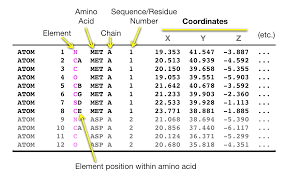 

Green Fluorescent Protein (GFP) is a naturally fluorescent protein originally isolated from the jellyfish Aequorea victoria. The discovery and development of GFP as a biological tool revolutionized cell biology and was recognized with the 2008 Nobel Prize in Chemistry awarded to Osamu Shimomura, Martin Chalfie, and Roger Y. Tsien.

GFP fluoresces green when exposed to blue or ultraviolet light because it forms an internal chromophore through an autocatalytic reaction involving its own amino acids. Structurally, GFP forms a beta-barrel with an alpha helix running through the center. The fluorescent chromophore sits inside the barrel. 

We'll use GFP as a first example and to get us oriented to PyMOL.

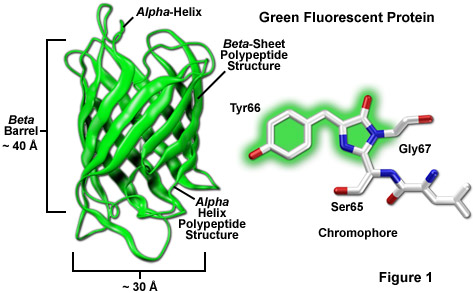

In [ ]:
#import GFP structure
cmd.reinitialize()
cmd.load("1ema.pdb", "GFP") #loads GFP PDB file; can use cmd.fetch to directly load pdb file but ran into firewall issues

cmd.ipython_image()

Lets go through different ways we can visualize the protein and highlight different aspects we're interested in

In [ ]:
cmd.show("cartoon") 
cmd.color("green","all")
cmd.bg_color("white")

cmd.ipython_image()

In [ ]:
#distinguish different secondary strcture
cmd.color("red", "ss h")   # alpha helices
cmd.color("yellow", "ss s") # beta sheets
cmd.color("green", "ss l")  # loops

cmd.ipython_image()

In [ ]:
#show specific residue
cmd.select("active_site", "resi 65")
cmd.show("sticks", "active_site")
cmd.color("magenta", "active_site")
cmd.ipython_image()

In [ ]:
cmd.select("hydrophobic", "resn ala+val+leu+ile+phe+met+trp")
cmd.color("orange", "hydrophobic")
cmd.show("sticks", "hydrophobic")

cmd.ipython_image()

In [ ]:
#show surface 
cmd.show("cartoon") 
cmd.color("green","all")
cmd.bg_color("white")
cmd.show("surface")
cmd.set("transparency", 0.4)
cmd.ipython_image()

Now let’s apply what we’ve learned to a biologically and clinically relevant example. TMEM63A is a mechanically activated ion channel that responds to membrane tension and mechanical force. It is part of a family of evolutionarily conserved mechanosensitive channels and is thought to play an important role in cellular responses to mechanical stimuli.

Importantly, several human mutations in TMEM63A have been identified in patients with hypomyelinating leukodystrophy, a rare childhood neurological disorder characterized by impaired myelin formation in the central nervous system. These disease-associated variants provide an opportunity to connect protein structure to physiological function and pathology.

In our lab, we are interested in understanding both the physiological role of TMEM63A in myelination and the structural basis of its mechanical gating properties. How does force translate into channel opening? Which transmembrane helices contribute to pore formation? Where are disease-associated mutations located within the 3D architecture? Are they positioned in the membrane core, near gating helices, or in cytoplasmic domains that may regulate channel behavior?

Using PyMOL, we will:

1. Load the experimentally determined structure of TMEM63A
2. Identify and highlight specific transmembrane domains
3. Programmatically annotate helices using a structured dataframe
4. Visualize the local environment surrounding residues of interest
5. Model a disease-relevant mutation
6. Examine how structural context might inform hypotheses about channel gating, stability, or dysfunction

By mapping mutations and functional regions onto the 3D structure, we can begin to ask mechanistic questions about how specific residues contribute to membrane embedding, helix packing, force transmission, and ultimately channel function.

This is where structural visualization becomes a bridge between molecular detail and physiological outcome.

In [ ]:
#load hTMEM63A
cmd.reinitialize() #clears GFP from window
cmd.load("8GRS.pdb", "TMEM63A")
cmd.hide("everything", "TMEM63A")
cmd.show("cartoon", "TMEM63A")
cmd.color("lightblue", "TMEM63A")
cmd.bg_color("white")
cmd.ipython_image()

Recent studies suggest that TMEM63A, which was originally characterized primarily as a mechanically activated ion channel, may also function as a lipid scramblase. This emerging dual-function model raises important questions about how a single protein architecture can support two mechanistically distinct processes: selective ion conduction and lipid translocation across the membrane. Ion channel activity typically involves the formation of a regulated aqueous pore, with specific transmembrane helices lining the conduction pathway and undergoing conformational changes during gating. In contrast, lipid scrambling requires a pathway that allows lipid headgroups to move between membrane leaflets, often involving different structural regions and potentially more hydrophilic or surface-exposed grooves within the transmembrane assembly.

Although PDB files provide detailed three-dimensional atomic coordinates of experimentally determined structures, they do not explicitly encode membrane topology or functional annotations such as which residues are extracellular, cytoplasmic, or embedded within the lipid bilayer. To interpret the structure in a physiological context, we therefore need to incorporate topological information from external resources such as UniProt. UniProt provides curated annotations of transmembrane domains, loop regions, and functional features that can be mapped onto structural coordinates. By extracting this topological information and organizing it into a structured format such as a pandas DataFrame, we can systematically define transmembrane domain boundaries and use them to guide visualization in PyMOL. This approach enables us to  highlight specific helices, compare regions implicated in ion conduction versus lipid scrambling, and more effectively interpret how structural organization relates to the protein’s physiological roles and disease-associated mutations.

In [ ]:
import pandas as pd

tm_domains = [(52, 74),
 (135, 167),
 (192, 217),
 (417, 444),
 (463, 490),
 (496, 532),
 (555, 586),
 (607, 624),
 (629, 651),
 (662, 689),
 (695, 709)]
tm_domains

In [ ]:
tm_df = pd.DataFrame(tm_domains, columns=["start", "end"])
tm_df["TM"] = ["TM" + str(i) for i in range(len(tm_df))]

tm_df

Now that we have TM numbering information, we need to create these selections in PyMOL. 

In [ ]:
for _, row in tm_df.iterrows():
    selection_string = f"chain A and resi {row.start}-{row.end}"
    cmd.select(row.TM, selection_string)

First, lets highlight the ion channel pore lining helices

In [ ]:
cmd.color("gray", "all")

highlight_tms = ["TM3", "TM4", "TM5", "TM6", "TM7"]

colors = {
    "TM3": "blue",
    "TM4": "blue",
    "TM5": "blue",
    "TM6": "blue",
    "TM7": "blue",
}

for tm in highlight_tms:
    cmd.color(colors[tm], tm)

cmd.ipython_image()

The residue W613 is thought to act as a gate for ion permeation. How would we visualize it?

In [ ]:
cmd.select("ion_gate", "resi 613")
cmd.show("sticks", "ion_gate")
cmd.color("magenta", "ion_gate")
cmd.ipython_image()

Can we do this for the transmembrane domains we know are involved in lipid permeation (TM0, 4, and 6) and the W473 residue?

In [ ]:
cmd.color("gray", "all")

highlight_tms = ["TM0", "TM4", "TM6"]

colors = {
    "TM0": "cyan",
    "TM4": "cyan",
    "TM6": "cyan"
}

for tm in highlight_tms:
    cmd.color(colors[tm], tm)
cmd.ipython_image()

In [ ]:
cmd.select("lipid_gate", "resi 473")
cmd.show("sticks", "lipid_gate")
cmd.color("magenta", "lipid_gate")
cmd.show("sticks", "organic") 
cmd.ipython_image()

Beautiful! It would be great if we could use this as a figure for publication. To export the image, we'll first clean up the visualization a bit.

In [ ]:
cmd.bg_color("white")


cmd.show("cartoon")

cmd.set("cartoon_smooth_loops", 1)
cmd.set("cartoon_fancy_helices", 1)
cmd.set("antialias", 2)
cmd.set("depth_cue", 0)   # removes fog effect

The last thing we'll do is called "ray tracing", which helps our figure by calculating realistic lighting and shadows and smooths the graphics. It can take a little while to process. 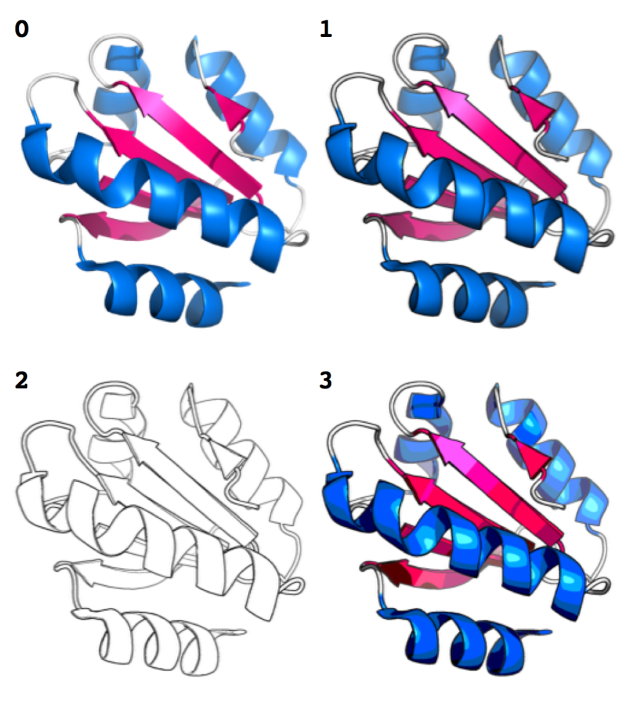

In [ ]:
cmd.set("ray_trace_mode", 1)
cmd.set("ray_shadows", 0)  # optional cleaner look
cmd.ray(3000, 1500)
cmd.ipython_image()

In [ ]:
cmd.png("TMEM63A_figure.png", dpi=600)

Now that we've examined a few structurally relevant parts of the protein, lets try to model a human disease mutation into the protein. G553V is one of a handful of human point mutations which lead to the hypomyelinating leukodystrophy discussed above. To continue our structure/function exploration, lets try to visualize how this mutation could affect the protein. 

First, we'll create a separate mutant object and preserve the WT structure for side by side comparison. 

In [ ]:
cmd.reinitialize()
cmd.load("8GRS.pdb", "WT")
cmd.create("Mutant_G553V", "WT")
cmd.ipython_image()

There is a mutagenesis wizard within PyMOL but I ran into errors when trying to get it to work offline since it didn't have access to the rotamer library. To get around this, we can perform the mutation manually by adding the mutant residue and removing the old sidechain atoms from glycine.

In [ ]:
cmd.alter("Mutant_G553V and chain A and resi 553", "resn='VAL'")
cmd.remove("Mutant_G553V and chain A and resi 553 and not name N+CA+C+O")

We can now rebuild for the appropriate valine sidechain geometry.

In [ ]:
cmd.rebuild()
cmd.ipython_image()

We can differentially color the mutant and WT colors for comparison. 

In [ ]:
cmd.show("sticks", "WT and resi 553")
cmd.show("sticks", "Mutant_G553V and resi 553")

cmd.color("cyan", "WT and resi 553")
cmd.color("magenta", "Mutant_G553V and resi 553")
cmd.ipython_image()
